In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from biodata.delimited import DelimitedReader, DelimitedWriter
import numpy as np
import seaborn as sns
import pybedtools
from statannotations.Annotator import Annotator
from statsmodels.stats.proportion import proportions_ztest
import hicstraw
import os
import itertools
from scipy.stats import mannwhitneyu
import json
import cooler
from cooltools import insulation
from collections import defaultdict

In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import utils

In [3]:
import matplotlib
font_dir = Path.cwd().parent / "font"
for font in ["Arial.ttf", "Arial_Bold.ttf"]:
    matplotlib.font_manager.fontManager.addfont(font_dir / font)
matplotlib.rcParams["font.family"] = "Arial"
bfontsize = 12
sfontsize = 9

In [4]:
PROJECT_DIR_d = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/PROcap/"
PROJECT_DIR_r = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/resources/"
PROJECT_DIR_o = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/"

# Loop frequency

## Get loop anchors

In [87]:
s = "HCT116"
ps = ["divergent", "unidirectional"]
ds = ["distal", "proximal"]
t = "minTSS"
labels = ["Up", "Unchanged"]
palette = ["#fec44f", "#d9d9d9"]

In [6]:
# chrom1, start, end, chrom2, start2, end2, PET count

inputfile = f"{PROJECT_DIR_r}ENCODE/ENCFF431BUN.bedpe.gz"
df_loop = pd.read_table(inputfile, header=None)
df_loop.head(2)

,0,1,2,3,4,5,6
0,chr10,66135,66716,chr10,76204,77233,3
1,chr10,76316,77462,chr10,86211,87169,4


In [7]:
# They submitted ChIA-PET loop file with PET count ≥ 3 to ENCODE

np.min(df_loop[6])

3

In [8]:
# It's okay to overlap with either anchor

outputfile = f"{PROJECT_DIR_o}temp/CTCF_loops.bed"
with DelimitedWriter(outputfile) as dw:
	for index, row in df_loop.iterrows():
		chrom, start, end, chrom2, start2, end2 = row[:-1]
		dw.write([chrom, start, end])
		dw.write([chrom2, start2, end2])

In [9]:
b1 = pybedtools.BedTool(f"{PROJECT_DIR_o}FIMO/{s}_CTCF_pos.bed")
b2 = pybedtools.BedTool(f"{PROJECT_DIR_o}temp/CTCF_loops.bed")
overlaps = b1.intersect(b2, u=True, f=1)
anchors = ["_".join(i.fields[:3]) for i in overlaps]

In [10]:
len(b1), len(anchors)

(3518, 2912)

## Get proportions

In [11]:
inputfile = f"{PROJECT_DIR_o}FIMO/{s}_CTCF_pos.json"
with open(inputfile, "r") as f:
	motifs = json.load(f)

In [12]:
inputfile = f"{PROJECT_DIR_o}labels/{s}_CTCF_DE.json"
with open(inputfile, "r") as f:
	DE_labels = json.load(f)

In [38]:
results = []
es = defaultdict(list)
for p, d in itertools.product(ps, ds):
	inputfile = f"{PROJECT_DIR_d}bed_plot/{s}_{p}_{d}.bed"
	with DelimitedReader(inputfile) as dr:
		for cols in dr:
			e = "_".join(cols[:3])
			if e in motifs and e in DE_labels[t]:
				es[d].append(e)
				e2 = f"{cols[0]}_{motifs[e][1]}_{motifs[e][2]}"
				if e2 in anchors:
					anchor = True
				else:
					anchor = False
				results.append([d, anchor, DE_labels[t][e]])
df_anchors = pd.DataFrame(results, columns=["Group", "Anchor", "Label"])
df_anchors.head(2)

,Group,Anchor,Label
0,distal,True,Unchanged
1,distal,True,Unchanged


In [14]:
# Proportion of elements with CTCF located at the loop with sPET count ≥ 3: Little differences

results = []
for d, label in itertools.product(ds, labels):
	df = df_anchors[(df_anchors["Group"]==d) & (df_anchors["Label"]==label)]
	results.append([d, label, len(df[df["Anchor"]==True]), len(df), len(df[df["Anchor"]==True])/len(df)*100])
df_prop = pd.DataFrame(results, columns=["Group", "Label", "No. anchors", "Total", "Proportion"])
df_prop.head(2)

,Group,Label,No. anchors,Total,Proportion
0,distal,Up,200,212,94.339623
1,distal,Unchanged,853,1006,84.791252


In [86]:
def plot_props(df, outputfile):
	fig, ax = plt.subplots(figsize=(1.8,2.2))
	hue_plot_params = {
						"data": df,
						"x": "Label",
						"y": "Proportion",
						"palette": palette,
						"hue": "Label",
						"legend": False,
						"alpha": 0.8
						}
	g = sns.barplot(ax=ax, **hue_plot_params)
	g.spines[["right", "top"]].set_visible(False)
	
	texts = []
	for label in labels:
		for index, row in df[df["Label"]==label].iterrows():
			texts.append(f"{row['No. anchors']}/{row['Total']}")
	for bar, text in zip(g.patches, texts):
		g.text(bar.get_x(), bar.get_height()+1, text, color="#000000", fontsize=sfontsize) 

	g.set_ylim([70,102])
	g.set_yticks([70,80,90,100])
	g.set_ylabel("TREs at loop anchors (%)", fontsize=bfontsize, fontweight="bold")
	g.tick_params(axis="y", labelsize=sfontsize)

	g.set_xlabel("")
	g.tick_params(axis="x", labelsize=bfontsize)
	for label in g.get_xticklabels():
	    label.set_fontweight('bold')
	
	pvalues = []
	successes = list(df["No. anchors"])
	nobs = list(df["Total"])
	x1, x2 = [0,1]
	pvalues.append(proportions_ztest([successes[x1], successes[x2]], [nobs[x1], nobs[x2]])[1])
	annotator = Annotator(g, [labels], **hue_plot_params)
	annotator.configure(text_format="star", verbose=False, text_offset=1, loc="outside", fontsize=sfontsize)
	annotator.set_pvalues(pvalues).annotate()

	plt.savefig(outputfile, bbox_inches="tight", dpi=300)

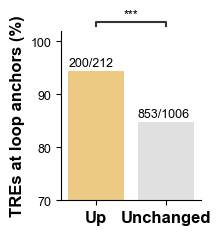

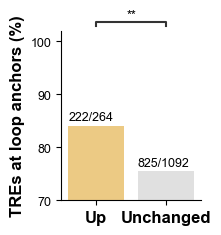

In [16]:
for d in ds:
	folder = "supp_figures/" if d == "distal" else "other_figures/"
	outputfile = f"{PROJECT_DIR_o}{folder}SuppFig7f.pdf"
	plot_props(df_prop[df_prop["Group"]==d], outputfile)

# Insulation score

## Convert .hic to .cool

In [17]:
# https://github.com/deeptools/HiCExplorer/issues/821
# https://github.com/open2c/cooler-binder/blob/master/cooler_cli.ipynb

def hic2cool(hic_file, cool_file, data_type, normalization, resolution):
	hic = hicstraw.HiCFile(hic_file)
	chrom_sizes = pd.Series({chrom.name: chrom.length for chrom in hic.getChromosomes() if chrom.name != "All"})
	
	with open(hic.getGenomeID() + '.size', 'w') as fsize:
	    for chrom in hic.getChromosomes():
	        if chrom.name != "All":
	            fsize.write(f"{chrom.name}\t{chrom.length}\n")

	with open(cool_file.replace('.cool', ".txt"), 'w') as fo:
	    for i in range(len(chrom_sizes)):
	        for j in range(i, len(chrom_sizes)):
	            chrom1 = chrom_sizes.index[i]
	            chrom2 = chrom_sizes.index[j]
				# Fetch a list of all the raw contacts on between chrom1 and chrom2 at XXX resolution
	            result = hicstraw.straw(data_type, normalization, hic_file, chrom1, chrom2, 'BP', resolution)
	            for k in range(len(result)):
	                start1 = result[k].binX
	                start2 = result[k].binY
	                value = result[k].counts
	                fo.write(f"{chrom1}\t{start1}\t{start1}\t{chrom2}\t{start2}\t{start2}\t{value}\n")
	
	# Create a cooler from a pre-binned matrix.
	os.system(f"cooler load -f bg2 {hic.getGenomeID()}.size:{resolution} {cool_file.replace('.cool', '.txt')} {cool_file}")
	# Matrix balancing 
	os.system(f"cooler balance -p 10 {cool_file}")

In [ ]:
hic_file = f"{PROJECT_DIR_r}ENCODE/ENCFF573OPJ.hic"
cool_file = f"{PROJECT_DIR_r}ENCODE/ENCFF573OPJ.cool"
data_type = "observed"
normalization = "NONE"
resolution = 10000
hic2cool(hic_file, cool_file, data_type, normalization, resolution)

INFO:cooler.cli.load:fields: {'chrom1': 0, 'start1': 1, 'end1': 2, 'chrom2': 3, 'start2': 4, 'end2': 5, 'count': 6}
INFO:cooler.cli.load:dtypes: {'chrom1': <class 'str'>, 'start1': <class 'int'>, 'end1': <class 'int'>, 'chrom2': <class 'str'>, 'start2': <class 'int'>, 'end2': <class 'int'>, 'count': <class 'numpy.int32'>}
INFO:cooler.cli.load:symmetric-upper: True
INFO:cooler.create:Writing chunk 0: /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/resources/ENCODE/tmp4vj7x_47.multi.cool::0
INFO:cooler.create:Creating cooler at "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/resources/ENCODE/tmp4vj7x_47.multi.cool::/0"
INFO:cooler.create:Writing chroms
INFO:cooler.create:Writing bins
INFO:cooler.create:Writing pixels
INFO:cooler.create:Writing indexes
INFO:cooler.create:Writing info
INFO:cooler.create:Writing chunk 1: /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/resources/ENCODE/tmp4vj7x_47.multi.cool::1
INFO:cooler.create:Creating cooler 

In [21]:
# Check the output

! cooler dump --header --balanced $PROJECT_DIR_r/ENCODE/ENCFF573OPJ.cool | awk 'NR==1 || $4 != ""' | head -n 3

bin1_id	bin2_id	count	balanced
87	87	587	0.481977
87	88	264	0.161714


## Get insulation scores

In [25]:
# https://cooltools.readthedocs.io/en/latest/notebooks/insulation_and_boundaries.html
# https://cooltools.readthedocs.io/en/latest/_modules/cooltools/api/insulation.html

clr = cooler.Cooler(f"{PROJECT_DIR_r}ENCODE/ENCFF573OPJ.cool")
windows = [3*resolution]
df_ins = insulation(clr, windows, verbose=True)
df_ins.head(2)

,chrom,start,end,region,is_bad_bin,log2_insulation_score_30000,n_valid_pixels_30000,boundary_strength_30000,is_boundary_30000
0,chr1,0,10000,chr1,True,NaN,0.0,NaN,False
1,chr1,10000,20000,chr1,True,NaN,0.0,NaN,False


In [117]:
set(df_ins[df_ins["log2_insulation_score_30000"].notna()]["is_bad_bin"])

{False, True}

In [23]:
outputfile = f"{PROJECT_DIR_o}temp/ENCFF573OPJ.insulation_score.txt"
df_ins.to_csv(outputfile, sep="\t", index=False)

In [118]:
# Anchor on the bin containing a given CTCF motif; 10 bins on both sides for plotting

n_bins = 20
bin_size = 3*resolution
df_features = {}
for d in ds:
	results = []
	index = []
	for e in es[d]:
		chrom = e.split("_")[0]
		mut_start = motifs[e][1]
		ind = mut_start//resolution
		df = df_ins[df_ins["chrom"]==chrom].reset_index(drop=True)
		if not np.isnan(df.loc[ind][f"log2_insulation_score_{bin_size}"]) and not df.loc[ind]["is_bad_bin"]:
			values = df.loc[ind-n_bins//2:ind+n_bins//2+1, f"log2_insulation_score_{bin_size}"].tolist()
			index.append(e)
			results.append(values)
	df_features[d] = pd.DataFrame(results, index=index)

In [119]:
for d in ds:
	print(d, len(es[d]), len(df_features[d]))

distal 1231 1222
proximal 1372 1356


In [120]:
df_reformat = {}
for d in df_features:
	df = df_features[d].reset_index()
	df_reformat[d] = pd.melt(df,
						  id_vars="index",
						  value_vars=list(df.columns[1:]),
						  var_name="Position",
						  value_name="Feature"
						  )
	df_reformat[d]["Feature"] = 2**df_reformat[d]["Feature"]
	df_reformat[d]["Label"] = df_reformat[d]["index"].map(DE_labels[t])

In [121]:
# Get the score of the middle bin for each element
# Get the average values for two groups; U test 

values = {}
d = "distal"
for label in labels:
	df = df_reformat[d][(df_reformat[d]["Label"]==label) & (df_reformat[d]["Position"]==10)]
	values[label] = df["Feature"].tolist()

In [122]:
np.mean(values[labels[0]]), np.mean(values[labels[1]])

(0.8674795560563728, 1.0157741625367582)

In [123]:
mannwhitneyu(values[labels[0]], values[labels[1]])

MannwhitneyuResult(statistic=79534.5, pvalue=2.283463125383696e-08)

In [128]:
def plot_scores(df, outputfile):
	fig, ax = plt.subplots(figsize=(2.5,2.5))
	g = sns.lineplot(data=df, x="Position", y="Feature", hue="Label", 
					 hue_order=labels, palette=palette, ax=ax)
	g.spines[["right", "top"]].set_visible(False)
	g.legend(title="", loc="lower left", fontsize=sfontsize, frameon=False)

	g.set_ylabel("Insulation score", fontsize=bfontsize, fontweight="bold")
	g.set_ylim([0.68,1.28])
	
	g.set_xlabel("Distance (kb)", fontsize=bfontsize, fontweight="bold")
	xtick_list = [5*n for n in range(5)]
	xticklabel_list = [-10*bin_size//1000, -5*bin_size//1000, 0, 5*bin_size//1000, 10*bin_size//1000]
	g.set_xticks(xtick_list)
	g.set_xticklabels(xticklabel_list)
	
	g.tick_params(labelsize=sfontsize)
	
	plt.savefig(outputfile, bbox_inches="tight", dpi=300)

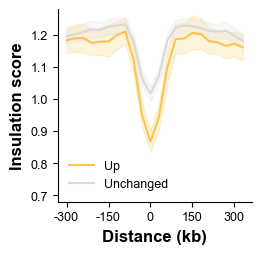

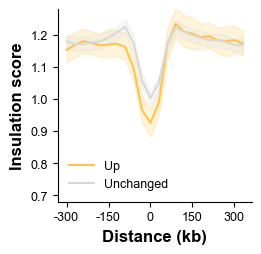

In [129]:
for d in ds:
	folder = "supp_figures/" if d == "distal" else "other_figures/"
	outputfile = f"{PROJECT_DIR_o}{folder}SuppFig7g.pdf"
	plot_scores(df_reformat[d], outputfile)